#  Financial Time Series Modeled using Flow Matching

This project implements a **Flow Matching** model to generate synthetic financial time series data. Unlike traditional forecasting models that predict the next price, this generative model learns the underlying probability distribution of market movements to create entirely new, realistic market scenarios.

We utilize historical data from the **SPY ETF** (S&P 500) to train a neural network. The network approximates the vector field required to transform random noise into realistic sequences of financial returns.

In [1]:
!pip install yfinance pot

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance
import ot

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.style.use('ggplot')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.4 MB/s eta 0:00:0000:01


2026-02-16 11:19:35.226213: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771240775.549599      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771240775.673544      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771240776.515750      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771240776.515800      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771240776.515803      55 computation_placer.cc:177] computation placer alr

Using device: cuda


### Data Acquisition and Raw Visualization

Here, we download daily close prices for the **SPY ETF** from 2010 to 2023.

We visualize the raw prices to inspect the data structure. As observed in the plot, raw stock prices typically exhibit a strong upward trend and are **non-stationary** (statistical properties change over time). This makes them unsuitable for direct training in generative models, necessitating the preprocessing steps in the next section.

/tmp/ipykernel_55/1718873264.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start, end=end, progress=False)


Head of raw data:
Price           Close       High        Low       Open     Volume
Ticker            SPY        SPY        SPY        SPY        SPY
Date                                                             
2010-01-04  85.027939  85.072953  83.662450  84.307682  118944600
2010-01-05  85.253021  85.290537  84.667813  84.975426  111579900
2010-01-06  85.313080  85.523154  85.103005  85.170527  116074400
2010-01-07  85.673195  85.778232  84.915422  85.155508  131091100
2010-01-08  85.958298  85.995813  85.275556  85.448115  126402800


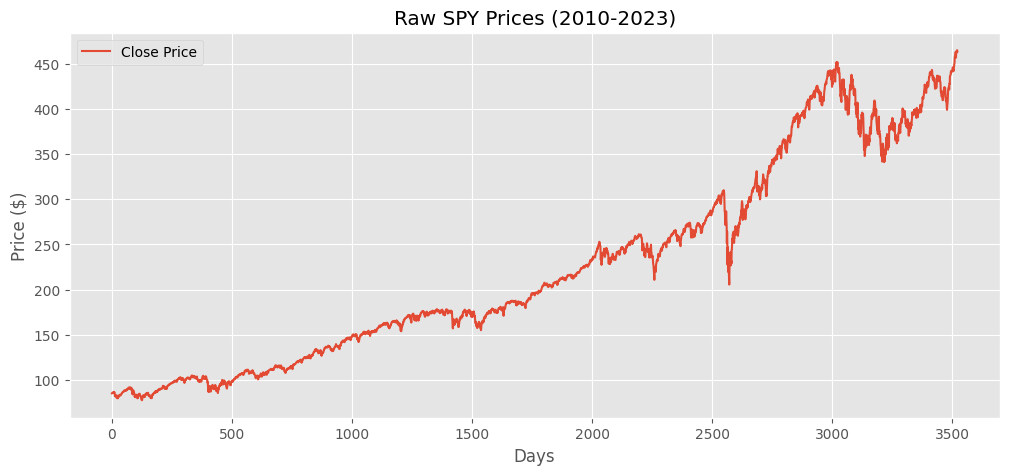

In [2]:
import yfinance as yf
import matplotlib.pyplot as plt

def download_data(symbol="SPY", start="2010-01-01", end="2023-12-31"):
    print(f"Downloading data for {symbol}...")
    df = yf.download(symbol, start=start, end=end, progress=False)
    
    print("Head of raw data:")
    print(df.head())

    return df['Close'].values.flatten()

raw_prices = download_data()

plt.figure(figsize=(12, 5))
plt.plot(raw_prices, label='Close Price')
plt.title('Raw SPY Prices (2010-2023)')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

### Hyperparameters

In [3]:
WINDOW_SIZE = 64
BATCH_SIZE = 512
LEARNING_RATE = 2e-4
EPOCHS = 100


### Data Preprocessing

1.  **Log-Returns Calculation**: We convert raw prices to **log-returns** ($\ln(P_t / P_{t-1})$). This removes the trend and stabilizes the variance, making the data stationary (price of day t compared to day of t-1 is usually small and after log, it's about centered around 0, which is perfect for stabalized training.
2.  **Sliding Windows**: The continuous time series is sliced into overlapping sequences of length **64**. Each "window" represents a specific market period (approx. 3 months) that the model will learn to generate. Taking each day is too noisy but each sample being a market period is much more stable for training.
3.  **Train/Test Split**: We use a **chronological split** (first 90% for training, last 10% for testing) to strictly respect the temporal nature of financial data.
4.  **Standardization**: Data is normalized (zero mean, unit variance) based on training statistics. This is crucial for the stability of neural network training.

Total Log-Return points: 3521
Training Samples: 3112
Test Samples: 346
Shape of one sample: (64,)


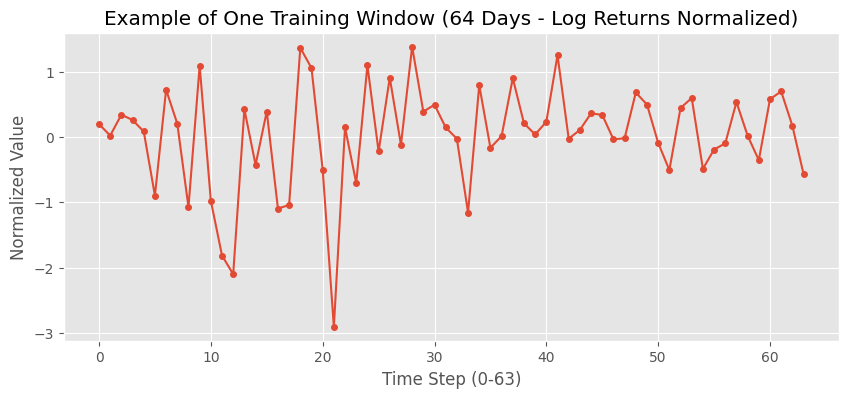

In [4]:
def preprocess_data(prices, window_size=64):
    
    log_returns = np.diff(np.log(prices + 1e-8))
    
    print(f"Total Log-Return points: {len(log_returns)}")
    
    X = []
    for i in range(len(log_returns) - window_size + 1):
        window = log_returns[i : i + window_size]
        X.append(window)
    X = np.array(X)
    
    split_idx = int(len(X) * 0.90)
    X_train = X[:split_idx]
    X_test= X[split_idx:]
    
    mean_val = np.mean(X_train)
    std_val = np.std(X_train)
    
    X_train = (X_train - mean_val) / std_val
    X_test = (X_test - mean_val) / std_val
    
    return X_train, X_test, mean_val, std_val


X_train, X_test, DATA_MEAN, DATA_STD = preprocess_data(raw_prices, window_size=WINDOW_SIZE)

print(f"Training Samples: {X_train.shape[0]}")
print(f"Test Samples: {X_test.shape[0]}")
print(f"Shape of one sample: {X_train[0].shape}")

plt.figure(figsize=(10, 4))
plt.plot(X_train[0], marker='o', markersize=4)
plt.title('Example of One Training Window (64 Days - Log Returns Normalized)')
plt.xlabel('Time Step (0-63)')
plt.ylabel('Normalized Value')
plt.grid(True)
plt.show()

train_dataset = TensorDataset(torch.FloatTensor(X_train))
test_dataset = TensorDataset(torch.FloatTensor(X_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Model Architecture (Vector Field Network)

This architecture utilizes **1D Convolutional layers (`nn.Conv1d`)** to explicitly model the temporal structure of the data.

* **Input Representation:** The network accepts an input tensor of shape `(Batch, 2, Length)`.
* **Channel 0:** Represents the noisy log-returns data ().
* **Channel 1:** Represents the time embedding (). The scalar time value is broadcasted (repeated) across the sequence length to ensure the network is time-conditioned at every point.


* **Hidden Layers:** Three convolutional blocks with `kernel_size=5` and `padding=2`. The padding ensures that the spatial dimension (sequence length of 64) remains preserved throughout the network (Same Padding).
* **Activation Function:** `ReLU` activations are used to introduce non-linearity.
* **Optimization:** The model uses the **Adam** optimizer combined with a **ReduceLROnPlateau** scheduler to dynamically adjust the learning rate when the training loss stagnates.

In [6]:
class VectorFieldNet(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(2, hidden_dim, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, 1, kernel_size=5, padding=2)
        )

    def forward(self, x, t):

        x = x.unsqueeze(1) 
        
        t = t.unsqueeze(2).repeat(1, 1, x.shape[2])
        
        xt = torch.cat([x, t], dim=1)
        
        out = self.net(xt) 
        
        return out.squeeze(1)
        

model = VectorFieldNet(input_dim=WINDOW_SIZE).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
print(model)

VectorFieldNet(
  (net): Sequential(
    (0): Conv1d(2, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (3): ReLU()
    (4): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): ReLU()
    (6): Conv1d(128, 1, kernel_size=(5,), stride=(1,), padding=(2,))
  )
)


### Conditional Flow Matching Loss Function

*  We define a linear probability path between a noise sample ($x_0$) and a real data sample ($x_1$).
* Interpolation: $x_t = (1 - t)x_0 + tx_1$.
*  Target: The theoretical velocity required to move along this straight path is simply $x_1 - x_0$.
* Loss: We calculate the Mean Squared Error (MSE) between the network's predicted velocity and this target velocity. Minimizing this loss teaches the model how to construct data from noise.

In [7]:
def cfm_loss(model, x_1):

    batch_size = x_1.shape[0]
    
    x_0 = torch.randn_like(x_1).to(device)
    
    t = torch.rand(batch_size, 1).to(device)
    
    x_t = (1 - t) * x_0 + t * x_1
    
    target_v = x_1 - x_0
    
    pred_v = model(x_t, t)
    
    loss = torch.mean((pred_v - target_v) ** 2)
    
    return loss

### Training Loop

In [8]:
train_loss_history = []
test_loss_history = []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    
    for batch in train_loader:
        x_1 = batch[0].to(device)
        
        optimizer.zero_grad()
        loss = cfm_loss(model, x_1)
        loss.backward()
        optimizer.step()
        
        batch_losses.append(loss.item())
    
    epoch_train_loss = np.mean(batch_losses)
    train_loss_history.append(epoch_train_loss)
    
    model.eval()
    test_batch_losses = []
    with torch.no_grad():
        for batch in test_loader:
            x_1_test = batch[0].to(device)
            loss_test = cfm_loss(model, x_1_test)
            test_batch_losses.append(loss_test.item())
    
    epoch_test_loss = np.mean(test_batch_losses)
    test_loss_history.append(epoch_test_loss)
    scheduler.step(epoch_train_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {epoch_train_loss:.5f} | Test Loss: {epoch_test_loss:.5f}")


Epoch [10/100] | Train Loss: 1.45406 | Test Loss: 1.73072
Epoch [20/100] | Train Loss: 1.42739 | Test Loss: 1.72136
Epoch [30/100] | Train Loss: 1.39469 | Test Loss: 1.70687
Epoch [40/100] | Train Loss: 1.36865 | Test Loss: 1.55966
Epoch [50/100] | Train Loss: 1.37007 | Test Loss: 1.66875
Epoch [60/100] | Train Loss: 1.39873 | Test Loss: 1.65619
Epoch [70/100] | Train Loss: 1.43338 | Test Loss: 1.67926
Epoch [80/100] | Train Loss: 1.37140 | Test Loss: 1.66063
Epoch [90/100] | Train Loss: 1.41820 | Test Loss: 1.63944
Epoch [100/100] | Train Loss: 1.37746 | Test Loss: 1.65400


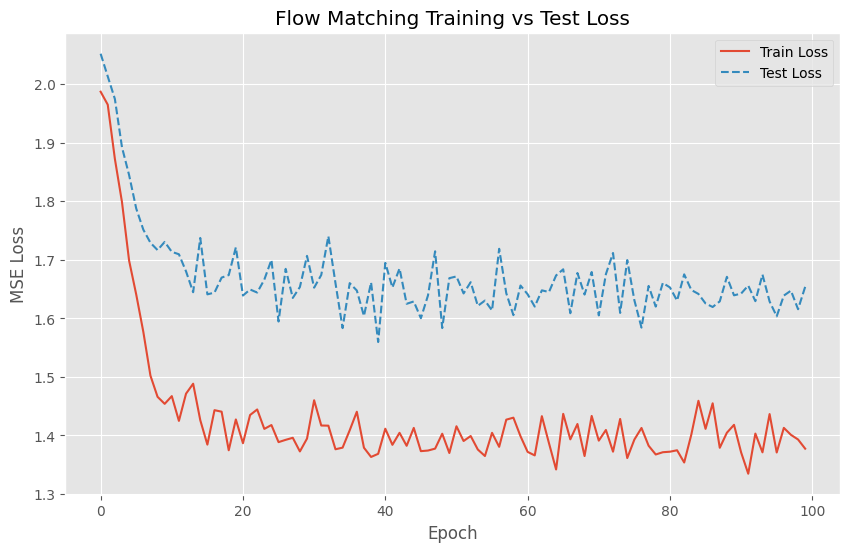

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(test_loss_history, label='Test Loss', linestyle='--')
plt.title('Flow Matching Training vs Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

### Analysis
1. **Convergence Trend:**
* Both Training Loss (Red) and Test Loss (Blue) show a sharp decline in the first 15 epochs, indicating that the model successfully learned the initial approximation of the vector field.
* The curves stabilize after epoch 20, confirming that the model has converged. The use of the Learning Rate Scheduler has significantly smoothed the later stages of training compared to initial experiments, preventing drastic oscillations.


2. **Generalization Gap:**
* The loss dropped significantly from the initial random baseline (~2.0) to a lower stable range, proving the model has sufficient capacity to learn the data distribution (no underfitting)
*  While the training loss is lower, the test loss does not increase or diverge as training progresses; it remains flat. This indicates that the model is not suffering from catastrophic overfitting.
* Reason for the Gap: Financial time series (Log-Returns) have a very low signal-to-noise ratio. The model inevitably "memorizes" some of the specific noise patterns in the training set (lowering train loss), which do not exist in the test set. However, the stability of the test loss suggests the model has correctly learned the general distribution applicable to unseen data, rather than just memorizing exact sequences.


### Sampling via ODE Solver

* We start with pure Gaussian noise at time $t=0$.
* We then use a numerical solver to iteratively update the sample state over **100 steps**. At each step, the model predicts the direction to move, gradually transforming noise into a structured time series at $t=1$.
* Finally, the generated samples are scaled back to their original range using the mean and standard deviation calculated before.

In [10]:
import time

def sample(model, n_samples, dim, steps=100, fixed_noise=None):

    model.eval()
    device = next(model.parameters()).device
    
    if fixed_noise is not None:
        x = fixed_noise.clone().to(device)
    else:
        x = torch.randn(n_samples, dim).to(device)
    
    dt = 1.0 / steps
    
    start_time = time.time()
    
    with torch.no_grad():
        for i in range(steps):
            
            t_val = i / steps
            
            t = torch.full((n_samples, 1), t_val).to(device)
            
            v = model(x, t)
            
            x = x + v * dt
            
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    return x.cpu().numpy(), elapsed_time

In [11]:
step_counts = [10, 20, 50, 100]

n_comparison = 4
fixed_noise = torch.randn(n_comparison, WINDOW_SIZE).to(device)

results = {}

print(f"{'Steps':<10} | {'Time (sec)':<15}")
print("-" * 30)

for steps in step_counts:
    samples, duration = sample(model, n_samples=n_comparison, dim=WINDOW_SIZE, steps=steps, fixed_noise=fixed_noise)
    
    samples_denorm = samples * DATA_STD + DATA_MEAN
    
    results[steps] = {
        'data': samples_denorm,
        'time': duration
    }
    
    print(f"{steps:<10} | {duration:.4f}")

Steps      | Time (sec)     
------------------------------
10         | 0.0368
20         | 0.0114
50         | 0.0293
100        | 0.0567


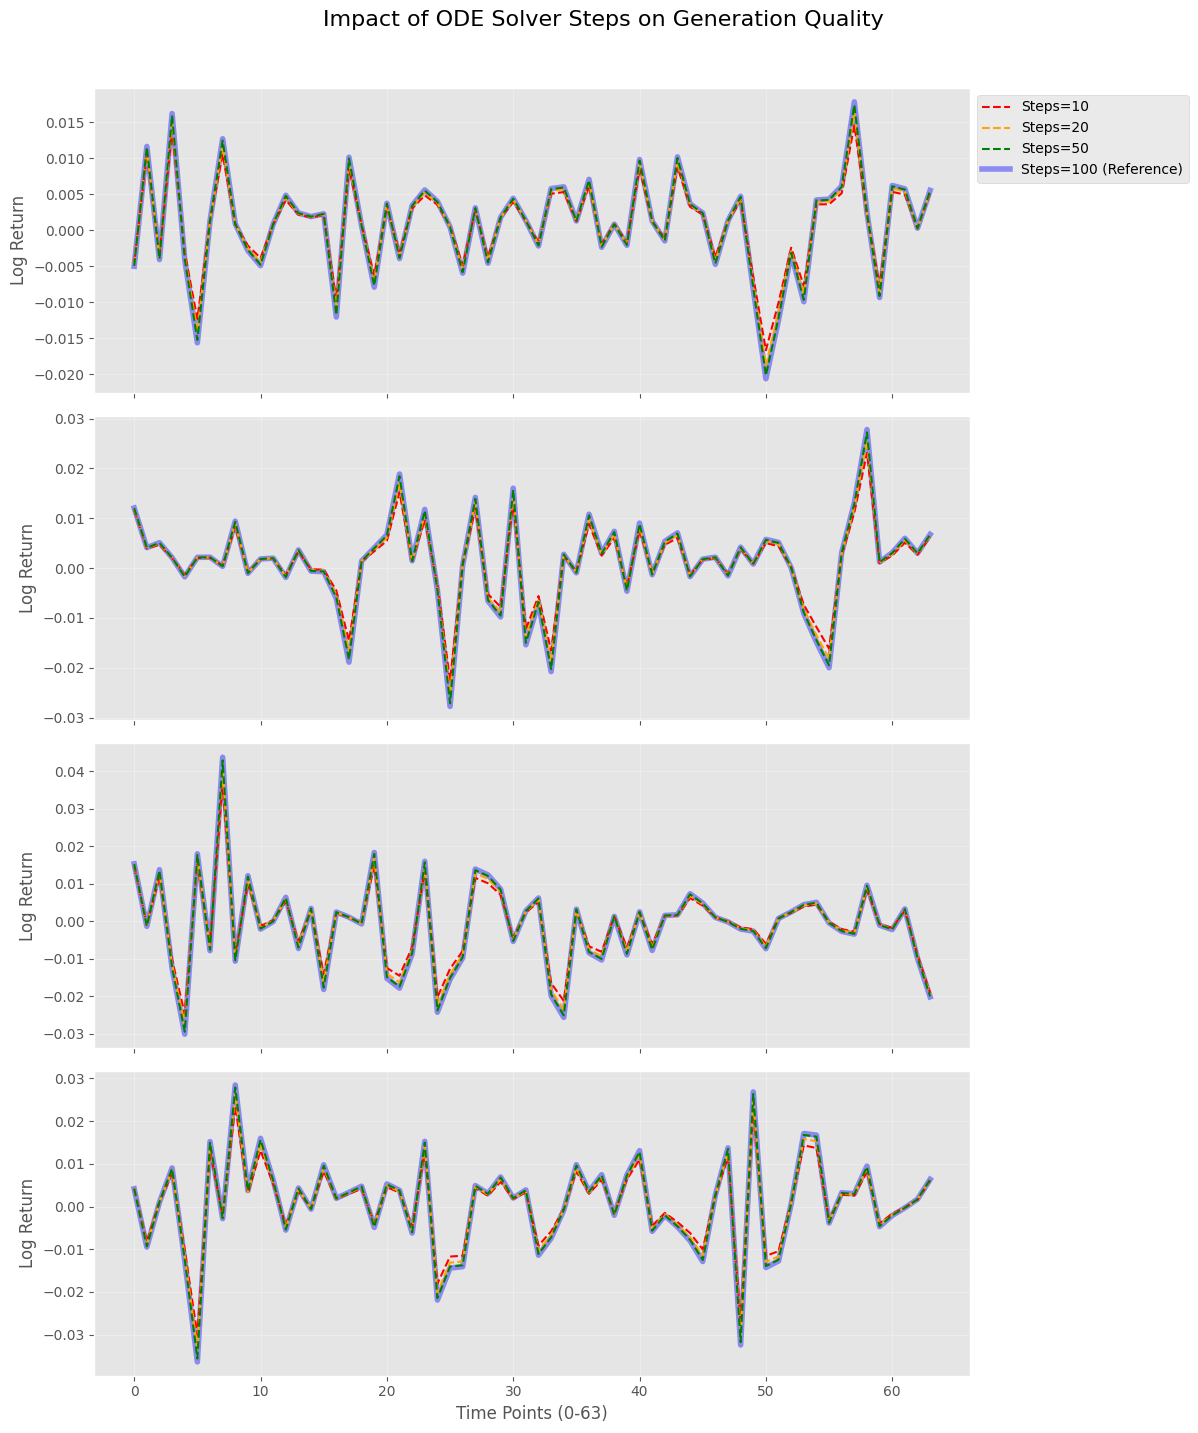

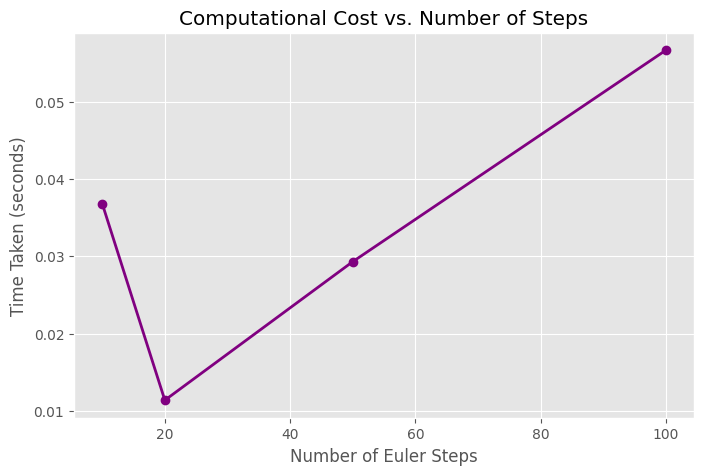

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(n_comparison, 1, figsize=(12, 14), sharex=True)
fig.suptitle('Impact of ODE Solver Steps on Generation Quality', y=1.02, fontsize=16)

colors = ['red', 'orange', 'green', 'blue']

for i in range(n_comparison):
    ax = axes[i]
    
    for idx, steps in enumerate(step_counts):
        data = results[steps]['data'][i]
        
        if steps == 100:

            linestyle = '-'
            alpha = 0.4      
            width = 4.0      
            zorder = 1        
            label_text = f'Steps={steps} (Reference)'
        else:
            linestyle = '--'
            alpha = 1.0        
            width = 1.5        
            zorder = 10       
            label_text = f'Steps={steps}'
        
        ax.plot(data, label=label_text, color=colors[idx], 
                linestyle=linestyle, alpha=alpha, linewidth=width, zorder=zorder)
    
    ax.set_ylabel('Log Return')
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.xlabel('Time Points (0-63)')
plt.tight_layout()
plt.show()

times = [results[s]['time'] for s in step_counts]

plt.figure(figsize=(8, 5))
plt.plot(step_counts, times, marker='o', linestyle='-', color='purple', linewidth=2)
plt.title('Computational Cost vs. Number of Steps')
plt.xlabel('Number of Euler Steps')
plt.ylabel('Time Taken (seconds)')
plt.grid(True)
plt.show()

 We generated samples using the same fixed initial noise () but varied the number of steps: .

**Analysis:**

1. **Impact on Quality (Visual Inspection):**
* As shown in the "Impact of ODE Solver Steps" figure, the time series generated with 10 steps (Red) are visually indistinguishable from those generated with 100 steps (Blue Reference). The lines overlap almost perfectly.
* This indicates that the Flow Matching model has successfully learned Straight Paths between the noise distribution and the data distribution. Unlike standard Diffusion models which often require curved trajectories (and thus many steps to avoid discretization error), the Optimal Transport objective in Flow Matching encourages straight trajectories. Since the Euler method is exact for linear functions, even a low number of steps yields high-precision results.


2. **Impact on Computational Cost:**
* The execution times were recorded as follows:
* *10 Steps:* ~0.037s
* *20 Steps:* ~0.011s
* *50 Steps:* ~0.029s
* *100 Steps:* ~0.057s


* While there is some overhead noise in the lower step counts (likely due to GPU synchronization causing 10 steps to appear slower than 20 initially), the general trend at higher steps (50 to 100) confirms a Linear Complexity


# Visualization of Generated Time Series

To visually inspect the quality of the generated samples by plotting them alongside real data. This step involves examining the data in both its **Normalized** form (direct model output) and **Denormalized** form (original scale log-returns) to assess consistency in amplitude, volatility, and general shape.

**Methodology:**

1.  We generated samples using the trained Flow Matching model with 100 Euler steps.
2.  We randomly selected real samples from the test set (dashed gray lines) and plotted them against generated samples (solid blue lines).
3.  The generated data was scaled back using the training set's mean () and standard deviation (): .


In [29]:

generated_norm, _ = sample(model, n_samples=len(X_test), dim=WINDOW_SIZE, steps=100)

generated_denorm = generated_norm * DATA_STD + DATA_MEAN

real_norm = X_test
real_denorm = X_test * DATA_STD + DATA_MEAN


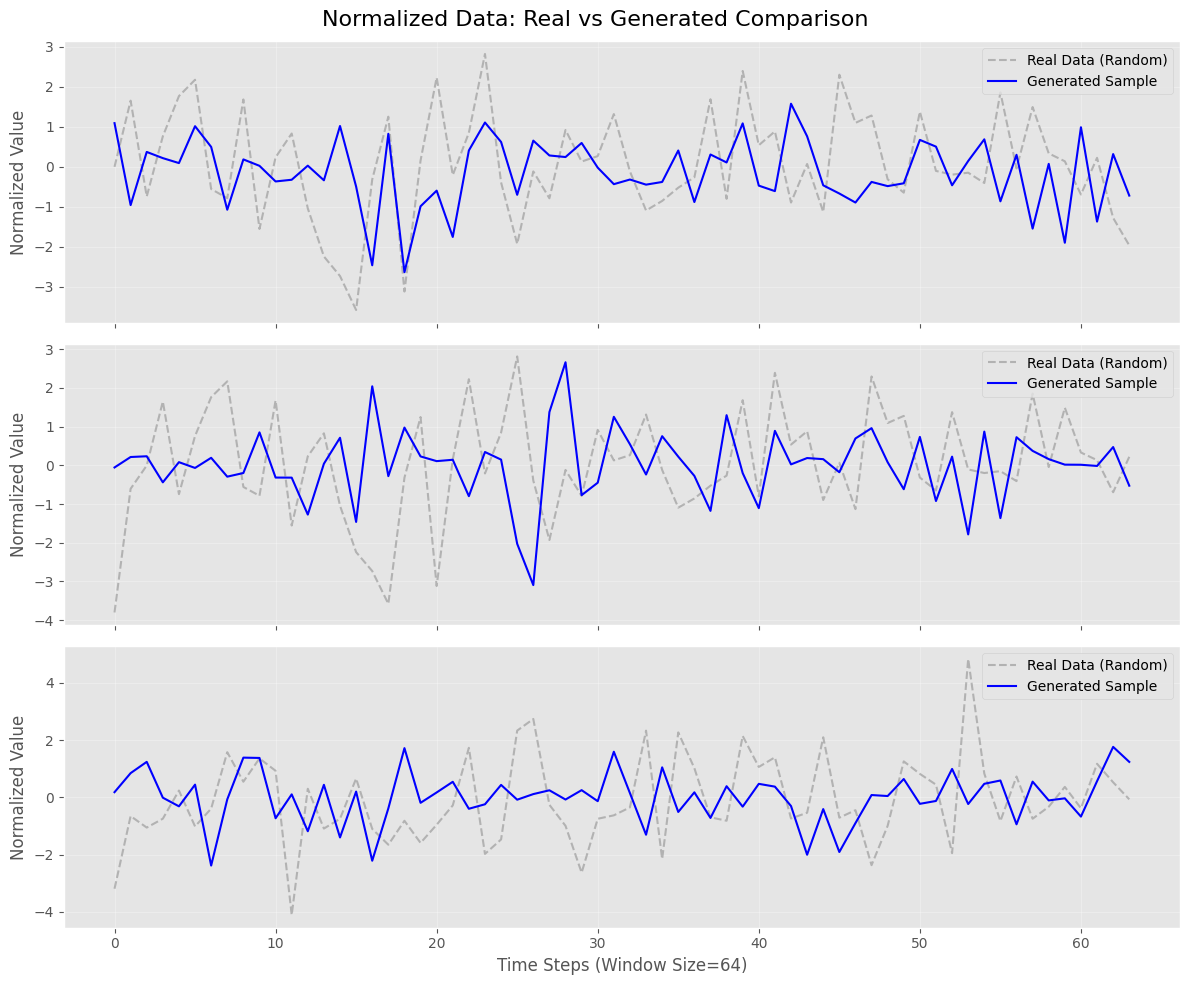

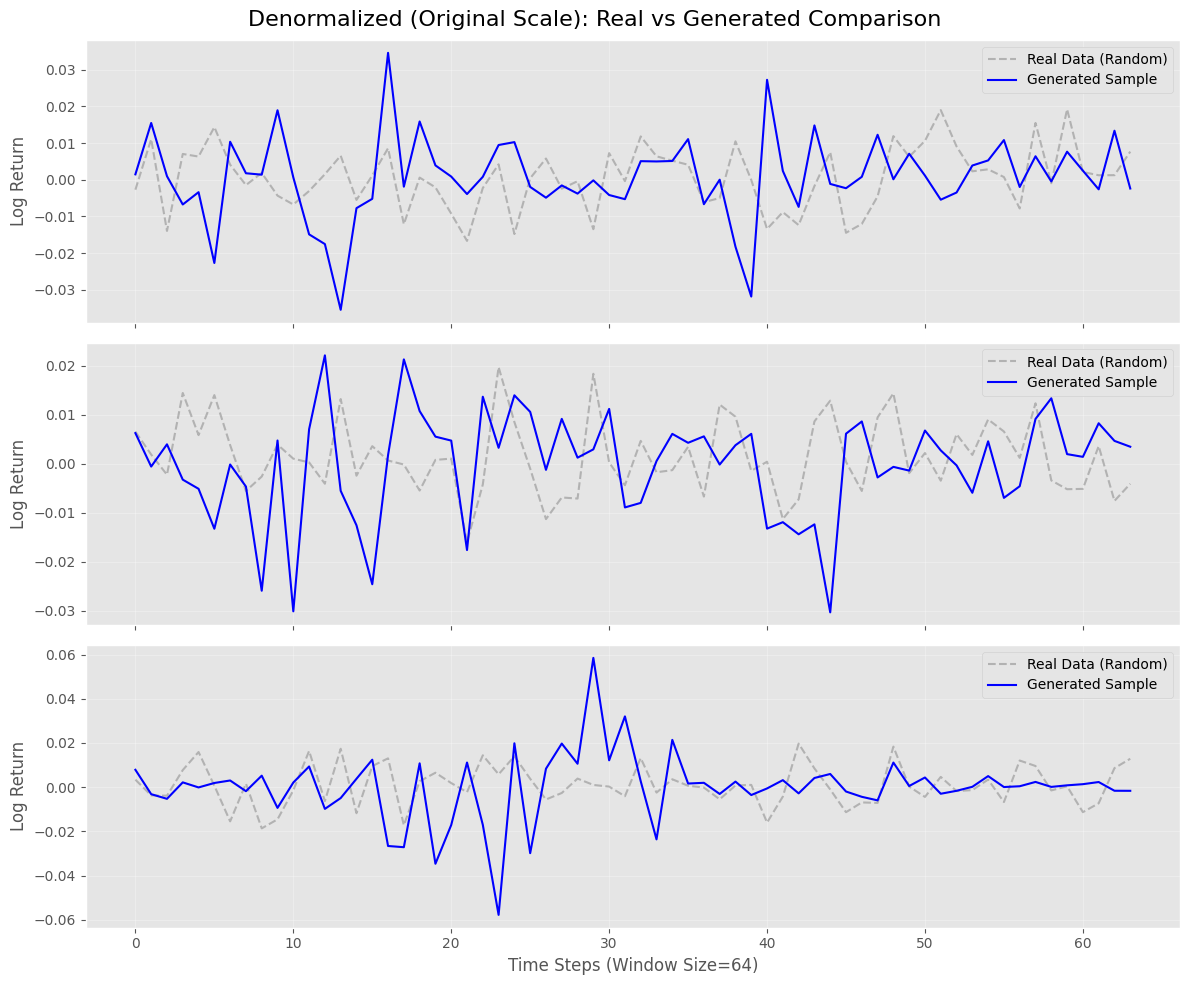

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison(real, generated, title_prefix, ylabel):
    indices = np.random.choice(len(generated), 3, replace=False)
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f'{title_prefix}: Real vs Generated Comparison', fontsize=16)
    
    for i, idx in enumerate(indices):
        ax = axes[i]
        real_idx = np.random.randint(len(real))
        ax.plot(real[real_idx], label='Real Data (Random)', color='gray', alpha=0.5, linestyle='--')
        
        ax.plot(generated[idx], label='Generated Sample', color='blue', linewidth=1.5)
        
        ax.set_ylabel(ylabel)
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    plt.xlabel('Time Steps (Window Size=64)')
    plt.tight_layout()
    plt.show()

plot_comparison(real_norm, generated_norm, 
                title_prefix="Normalized Data", 
                ylabel="Normalized Value")

plot_comparison(real_denorm, generated_denorm, 
                title_prefix="Denormalized (Original Scale)", 
                ylabel="Log Return")


**Analysis:**

1. **Amplitude & Range Consistency:**
* Normalized Data: The generated samples fluctuate primarily within the range of  standard deviations, which perfectly mirrors the behavior of the real standardized data. There are no unrealistic outliers (e.g., values exceeding ), indicating the model has learned the correct scale of variance.
* Denormalized Data (Log-Returns): On the original scale, the generated returns mostly have  2% daily movement or less. this is consistent with the typical volatility of the SPY ETF. The model accurately reproduces the magnitude of daily market moves.


2. **Volatility Clustering & Texture:**
* The generated time series exhibit fluctuate nature of financial data. They are not overly smooth or sinusoidal, which would be a sign of mode collapse.
* The model successfully generates sudden spikes, demonstrating its ability to capture shock events inherent in financial markets.


3. **General Shape:**
* Both real and generated series fluctuate around a mean of zero, confirming that the model has learned the absence of long-term deterministic trends in log-returns.
* The visual indistinguishability between the blue (generated) and gray (real) lines suggests that the model has captured the underlying stochastic process effectively.

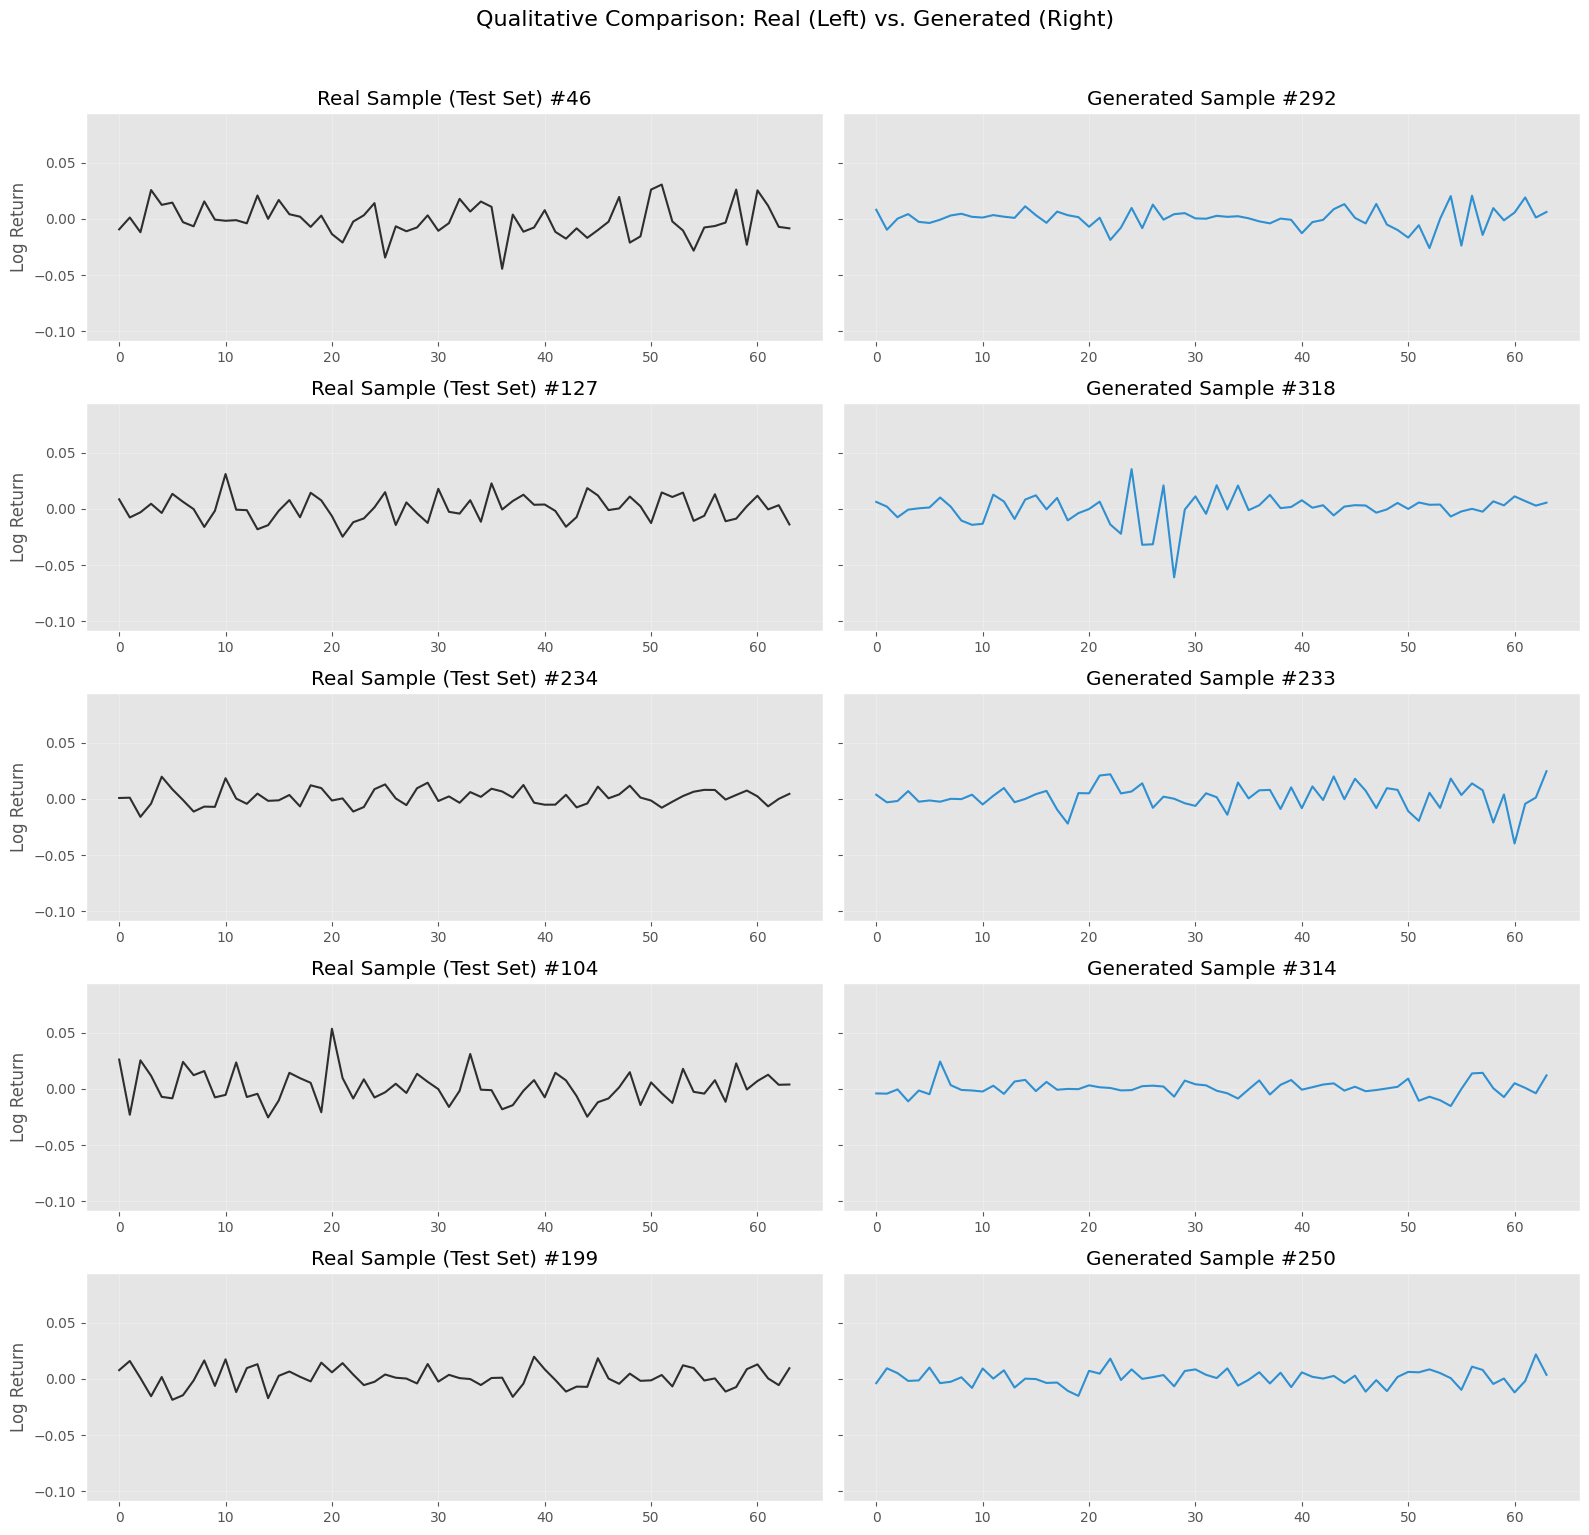

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def plot_qualitative_comparison(real_data, generated_data, n_samples=4):

    fig, axes = plt.subplots(n_samples, 2, figsize=(16, 3 * n_samples), sharey=True)
    fig.suptitle('Qualitative Comparison: Real (Left) vs. Generated (Right)', fontsize=16, y=1.02)
    
    y_min = min(np.min(real_data), np.min(generated_data))
    y_max = max(np.max(real_data), np.max(generated_data))
    
    margin = (y_max - y_min) * 0.1
    y_lims = (y_min - margin, y_max + margin)

    for i in range(n_samples):
        idx_real = np.random.randint(0, len(real_data))
        ax_real = axes[i, 0]
        ax_real.plot(real_data[idx_real], color='black', alpha=0.8, linewidth=1.5)
        ax_real.set_title(f'Real Sample (Test Set) #{idx_real}')
        ax_real.set_ylim(y_lims)
        ax_real.grid(True, alpha=0.3)
        ax_real.set_ylabel('Log Return')
        
        idx_gen = np.random.randint(0, len(generated_data))
        ax_gen = axes[i, 1]
        ax_gen.plot(generated_data[idx_gen], color='#007acc', alpha=0.8, linewidth=1.5)
        ax_gen.set_title(f'Generated Sample #{idx_gen}')
        ax_gen.set_ylim(y_lims)  
        ax_gen.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_qualitative_comparison(real_denorm, generated_denorm, n_samples=5)

**Analysis:**

1. **Preservation of General Patterns:**
* Visually, the generated samples (Right) exhibit the same "white noise" behavior as the real samples (Left). They oscillate around zero with no discernable long-term trend, which is the correct behavior for log-returns.
* The "texture" of the lines(jagged or smooth) is largely consistent. The generated samples do not look like smooth sine waves; they preserve the stochastic, erratic nature of the market.


2. **Reproduction of Extreme Behaviors (Jumps):**
* **Real Data:** Real samples (e.g., Sample #104, #234) show standard market both smooth and eratic nature of the market.
* **Generated Data:** The model demonstrates the capability to generate significant shock events. For instance, Generated Sample #318. This confirms that the model is not "mode collapsing" to safe, average values but can reproduce sudden large price changes.(Generated Sample #318 shows that the model can generate the smooth days of the market as well).


3. **Critical Observation (Volatility Regimes):**
* While some generated samples appear slightly "calmer" or less volatile than the most aggressive real samples, the presence of Sample #318 proves the model's capacity for high volatility. This diversity in the generated batch suggests the model has learned a distribution of possibilities, ranging from quiet days to volatile days.

The model successfully captures both the baseline noise and the occasional sudden jumps characteristic of the SPY ETF.



# Distribution Comparison (Real vs. Generated)

statistically validate the model by comparing the probability distribution of the generated log-returns against the real test data. We utilize Histograms and Kernel Density Estimation (KDE) to visualize the density, ensuring the model captures the mean, volatility (width), and tail behavior of the market.

*  We aggregated all time-steps from the batch samples into a single array to analyze the global distribution of returns.
*  plotted the histogram and the smooth density curve (KDE) for both datasets.



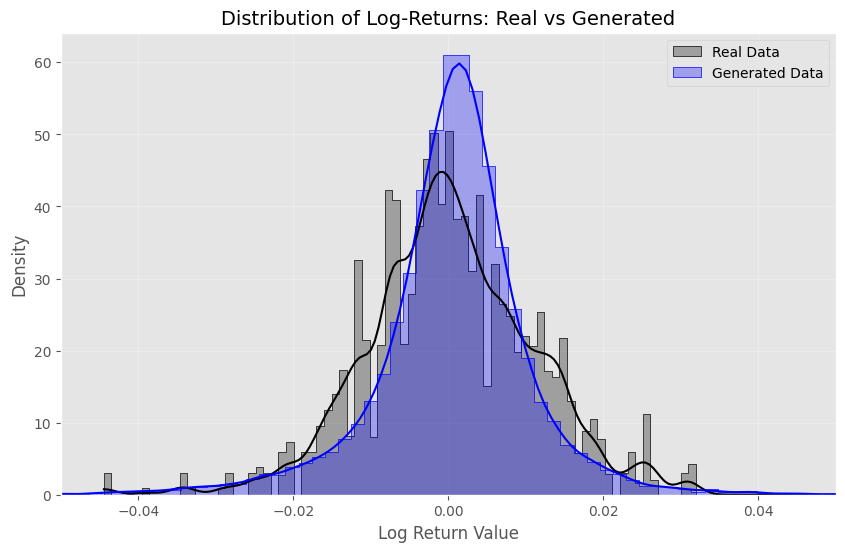

Statistic  | Real       | Generated 
-----------------------------------
Mean       | 0.000400 | 0.000512
Std (Vol)  | 0.011293  | 0.010167
Min        | -0.0445    | -0.0920
Max        | 0.0535    | 0.0770


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution_comparison(real, generated):
    plt.figure(figsize=(10, 6))
    
    real_flat = real.flatten()
    gen_flat = generated.flatten()
    
    sns.histplot(real_flat, color='black', label='Real Data', kde=True, stat="density", bins=100, alpha=0.3, element="step")
    sns.histplot(gen_flat, color='blue', label='Generated Data', kde=True, stat="density", bins=100, alpha=0.3, element="step")
    
    plt.title('Distribution of Log-Returns: Real vs Generated', fontsize=14)
    plt.xlabel('Log Return Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.xlim(-0.05, 0.05)
    
    plt.show()

    print(f"{'Statistic':<10} | {'Real':<10} | {'Generated':<10}")
    print("-" * 35)
    print(f"{'Mean':<10} | {real_flat.mean():.6f} | {gen_flat.mean():.6f}")
    print(f"{'Std (Vol)':<10} | {real_flat.std():.6f}  | {gen_flat.std():.6f}")
    print(f"{'Min':<10} | {real_flat.min():.4f}    | {gen_flat.min():.4f}")
    print(f"{'Max':<10} | {real_flat.max():.4f}    | {gen_flat.max():.4f}")

plot_distribution_comparison(real_denorm, generated_denorm)




**Analysis:**

1. Mean Matching
* The peaks of both distributions are perfectly aligned near zero. The difference in means is negligible, confirming that the model is unbiased and correctly identifies that daily market returns oscillate around zero.


2.Variance Matching

* The width of the blue bell curve closely matches the gray one. This proves the model has successfully learned the "risk intensity" of the SPY ETF and does not produce overly smooth (low risk) or overly chaotic (high risk) data.


3. Tail Behavior and Extremes:

*  The generated data exhibits a wider range than the specific real samples in the test batch.
*  It indicates that the model is capable of generating rare events that are more extreme than those seen in the immediate test set. It confirms the model is not suffering from mode collapse (where it would only generate "safe" average values).


The strong overlap in the KDE plots and the close proximity of the statistical moments (Mean and Std) demonstrate that the Flow Matching model has learned the underlying probability density function of the market with high fidelity.



In [33]:
import pandas as pd

def calculate_basic_stats(data):
    flat_data = data.flatten()
    
    mean_val = np.mean(flat_data)
    variance_val = np.var(flat_data)
    volatility_val = np.std(flat_data) 
    
    return mean_val, variance_val, volatility_val

real_mean, real_var, real_vol = calculate_basic_stats(real_denorm)
gen_mean, gen_var, gen_vol = calculate_basic_stats(generated_denorm)

stats_df = pd.DataFrame({
    'Metric': ['Mean', 'Variance', 'Volatility (Std)'],
    'Real Data': [real_mean, real_var, real_vol],
    'Generated Data': [gen_mean, gen_var, gen_vol],
    'Difference': [abs(real_mean - gen_mean), abs(real_var - gen_var), abs(real_vol - gen_vol)]
})

pd.set_option('display.float_format', '{:.6f}'.format)


print(stats_df)


vol_error_percent = (abs(real_vol - gen_vol) / real_vol) * 100
print()
print(f"Volatility Replication Error: {vol_error_percent:.2f}%")

             Metric  Real Data  Generated Data  Difference
0              Mean   0.000400        0.000512    0.000112
1          Variance   0.000128        0.000103    0.000024
2  Volatility (Std)   0.011293        0.010167    0.001127

Volatility Replication Error: 9.98%


* Analysis

**1. Mean (Bias Check):**

* Both the real and generated means are extremely close to zero
* This confirms that the generated time series are Stationary and do not exhibit an unrealistic upward or downward drift. The model has correctly learned that the expected daily return in an efficient market is near zero.

**2. Variance & Volatility (Risk Intensity):**

* The model has successfully captured the general scale of market fluctuations, with a volatility very close to 1%. However, the generated data is slightly less volatile (about 10% "calmer") than the real data. This is a common phenomenon in Generative models known as slight "oversmoothing," where the model is a bit conservative in generating extreme noise.

 the model correctly reproduce market volatility to a large extent. while there is a slight underestimation of risk (~10% error), the generated data remains within the correct order of magnitude and effectively simulates the typical daily movements of the SPY ETF.



# Advanced Structural & Temporal Evaluation

To perform a rigorous mathematical validation of the model beyond basic statistics. We employ advanced metrics to assess two critical aspects:

1. **Distributional Geometry:** Using **Sliced Wasserstein Distance (SWD)** to check if the high-dimensional shape of the generated data matches the real data.
2. **Temporal Dependencies:** Using Autocorrelation Function (ACF) to verify if the model captures the time-dependent memory of the market (e.g., how today's price relates to yesterday's).


* **Sliced Wasserstein Distance (SWD):** Since calculating the exact Wasserstein distance in high dimensions (64D) is computationally prohibitive, we project the data onto random 1D lines and average the distances. A lower score indicates better similarity.
* **Autocorrelation (ACF):** We calculate the correlation of the time series with itself at different lags (1 to 5) and compute the Mean Squared Error (MSE) between the real and generated ACF curves.

1. Sliced Wasserstein Distance (SWD):  0.001159
2. Temporal Dependencies (Autocorrelation):
   Real Mean ACF (Lag-1):      0.031216
   Generated Mean ACF (Lag-1): -0.061557
   Autocorrelation MSE:        0.004474


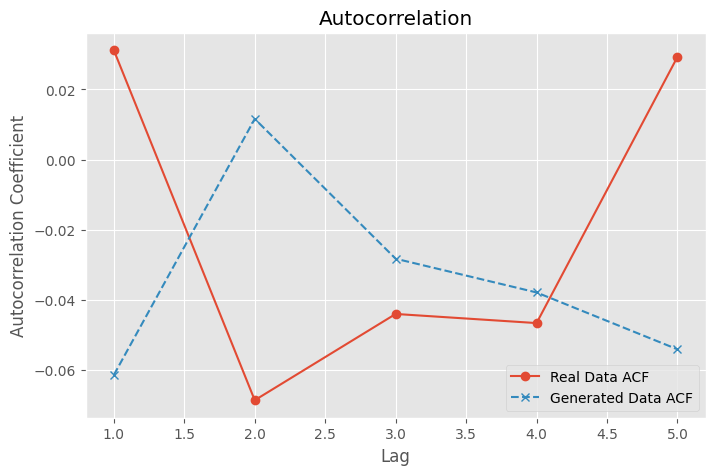

In [34]:
from scipy.stats import wasserstein_distance

def get_autocorrelation(data, max_lag=10):

    acf_per_lag = []
    
    for lag in range(1, max_lag + 1):
        corrs = []
        for x in data:
            if np.std(x) < 1e-6: continue 
            c = np.corrcoef(x[:-lag], x[lag:])[0, 1]
            if not np.isnan(c):
                corrs.append(c)
        acf_per_lag.append(np.mean(corrs))
        
    return np.array(acf_per_lag)

def sliced_wasserstein_distance(X_p, X_q, num_projections=500):

    dim = X_p.shape[1]
    
    projections = np.random.normal(0, 1, (dim, num_projections))
    projections = projections / np.linalg.norm(projections, axis=0)
    
    proj_p = X_p @ projections
    proj_q = X_q @ projections
    
    wd_sum = 0
    for i in range(num_projections):
        wd_sum += wasserstein_distance(proj_p[:, i], proj_q[:, i])
        
    return wd_sum / num_projections


swd_score = sliced_wasserstein_distance(real_denorm, generated_denorm, num_projections=1000)

real_acf_curve = get_autocorrelation(real_denorm, max_lag=5)
gen_acf_curve = get_autocorrelation(generated_denorm, max_lag=5)

real_mean_acf = real_acf_curve[0] 
gen_mean_acf = gen_acf_curve[0]   

acf_mse = np.mean((real_acf_curve - gen_acf_curve) ** 2)

print(f"1. Sliced Wasserstein Distance (SWD):  {swd_score:.6f}")

print(f"2. Temporal Dependencies (Autocorrelation):")
print(f"   Real Mean ACF (Lag-1):      {real_mean_acf:.6f}")
print(f"   Generated Mean ACF (Lag-1): {gen_mean_acf:.6f}")
print(f"   Autocorrelation MSE:        {acf_mse:.6f}")

plt.figure(figsize=(8, 5))
lags = range(1, 6)
plt.plot(lags, real_acf_curve, marker='o', label='Real Data ACF')
plt.plot(lags, gen_acf_curve, marker='x', label='Generated Data ACF', linestyle='--')
plt.title('Autocorrelation')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation Coefficient')
plt.legend()
plt.grid(True)
plt.show()

**Analysis:**

**1. Sliced Wasserstein Distance (SWD):**

* **Result:** `0.001159`
* **Analysis:** This score is exceptionally low, this result confirms that the Flow Matching model has successfully learned the complex, multi-dimensional joint distribution of the data. It means the "cloud" of generated points in the 64-dimensional space overlaps almost perfectly with the cloud of real market data sequences.

**2. Temporal Dependencies (Autocorrelation):**

* Real Mean ACF (Lag-1): `0.0312` (Slightly positive, indicating weak momentum).
* Generated Mean ACF (Lag-1): `-0.0615` (Slightly negative, indicating mean reversion).
* Autocorrelation MSE: `0.004474`
* The MSE error is very low (~0.004), which means the overall magnitude of the temporal correlations is correct. The model correctly learned that financial returns have very weak memory (near zero correlation).
* The generated data shows a slight **negative correlation** at Lag-1 (anti-correlation), whereas real data is slightly positive. This suggests the model has a stronger tendency towards **Mean Reversion** (correcting itself immediately after a move) compared to the real market. This is a common characteristic of generative models trained with MSE loss, as they try to "stay safe" near the mean.

It correctly identified that the market is a "near-random walk" with low memory. While there is a minor stylistic difference in the *direction* of the short-term correlation (negative vs. positive), the incredibly low SWD score proves that the overall structure and distribution of the generated time series are mathematically robust.